# Binary Suffix Learning in Non-Binary Bases — Full Overnight Experiment

**Task:** Given $n$ encoded as base-$B$ digits, predict $n \bmod 2^p$.

This notebook runs the full $(B, p)$ experimental grid with:
- Architecture matching Charton & Narayanan (2025): 4-layer encoder, 1-layer decoder, dim 512, 8 heads
- On-the-fly data generation (no stored datasets)
- Checkpoint saving after every experiment for Colab disconnect resilience
- Per-class accuracy breakdown to detect step-like learning patterns
- Linear probing of hidden representations

**Estimated runtime:** 6–12 hours on Colab Pro (T4/V100/A100).

## 0. Mount Google Drive for Persistent Checkpoints

In [3]:
import os

# Mount Google Drive so checkpoints survive disconnects
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/binary_suffix_experiment'
    IN_COLAB = True
except ImportError:
    SAVE_DIR = './binary_suffix_experiment'
    IN_COLAB = False

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Checkpoint directory: {SAVE_DIR}")
print(f"Running in Colab: {IN_COLAB}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint directory: /content/drive/MyDrive/binary_suffix_experiment
Running in Colab: True


## 1. Imports & Device Setup

In [4]:
import math
import time
import json
import pickle
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, IterableDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch: {torch.__version__}')

Device: cuda
GPU: NVIDIA L4
Memory: 23.7 GB
PyTorch: 2.10.0+cu128


## 2. Configuration

All experiment parameters in one place. Edit `BASES` and `P_VALUES` to adjust the grid.

In [5]:
# ── Reproducibility ─────────────────────────────────────────────────────────
GLOBAL_SEED = 1337
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

# ── Run controls ────────────────────────────────────────────────────────────
RUN_SWEEP = True
RUN_ANALYSIS = True
RUN_PROBES = True

# On reruns, skip experiments whose saved accuracy is already good enough.
SKIP_SUCCESSFUL_ON_SWEEP = True

# Mark a run as "successful / learned" once it reaches this accuracy.
SUCCESS_ACC_THRESHOLD = 0.90

# Only allow patience-based early stopping AFTER the run has already crossed
# this threshold. This prevents long flat plateaus from getting cut off.
EARLY_STOP_ACC_THRESHOLD = 0.98

# Optional: force specific experiments to rerun even if they already succeeded.
# Example: FORCE_RERUN = {(3, 4), (5, 6)}
FORCE_RERUN = set()

# If False, unsuccessful runs resume from their saved checkpoint/history.
# If True, unsuccessful runs start over from scratch.
RETRAIN_FROM_SCRATCH = False

# ── Experimental grid ──────────────────────────────────────────────────────
# Full grid from project outline:
# BASES = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 16, 24, 27, 32]
# P_VALUES = [1, 2, 3, 4, 5, 6, 7, 8]

# First pass reduced grid for quick iteration:
BASES = [2, 3, 5, 8, 10, 16, 27]
P_VALUES = [1, 2, 4, 6, 8]

# ── Architecture (matching Charton & Narayanan) ─────────────────────────────
D_MODEL = 512
N_HEADS = 8
ENC_LAYERS = 4
#DEC_LAYERS = 1
DIM_FF = 4 * D_MODEL  # 2048
DROPOUT = 0.1

# ── Training ────────────────────────────────────────────────────────────────
N_MAX = 10**8            # sample n from [1, N_MAX]
EPOCH_SIZE = 300_000     # examples per epoch (matches Charton's convention)
N_EPOCHS = 40            # 40 epochs = 12M examples per experiment
N_EPOCHS_ODD = 400       # odd bases need much longer training (grokking!)
N_EPOCHS_EVEN_MIXED = 80 # even non-power-of-2 bases get extra epochs too
BATCH_SIZE = 1024
LR = 3e-4
WARMUP_STEPS = 500
EVAL_SIZE = 50_000       # test set size per evaluation

# ── Checkpointing / early stopping ─────────────────────────────────────────
SAVE_EVERY = 1
MIN_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 4
MIN_DELTA = 1e-3

# ── Logging ─────────────────────────────────────────────────────────────────
LOG_INTERVAL = 200       # print loss every N batches
EVAL_EVERY = 1           # evaluate every N epochs

print(f'Grid: {len(BASES)} bases × {len(P_VALUES)} p-values = {len(BASES)*len(P_VALUES)} experiments')
print(f'Architecture: enc={ENC_LAYERS}L, d={D_MODEL}, h={N_HEADS}')
print(f'Training: up to {N_EPOCHS} epochs × {EPOCH_SIZE:,} examples = {N_EPOCHS*EPOCH_SIZE/1e6:.1f}M examples per experiment')
print(f'Success threshold: {SUCCESS_ACC_THRESHOLD:.2f}')
print(f'Early-stop threshold: {EARLY_STOP_ACC_THRESHOLD:.2f}')

Grid: 7 bases × 5 p-values = 35 experiments
Architecture: enc=4L, d=512, h=8
Training: up to 40 epochs × 300,000 examples = 12.0M examples per experiment
Success threshold: 0.90
Early-stop threshold: 0.98


## 3. Data Generation (On-the-Fly)

We use an `IterableDataset` that generates data on the fly, so we never store datasets.
This matches the Charton approach of training on freshly generated random examples.

In [6]:
def int_to_base_digits(n: int, base: int) -> list:
    """Convert n to base-B digits, MSD first."""
    if n == 0:
        return [0]
    digits = []
    while n > 0:
        digits.append(n % base)
        n //= base
    return digits[::-1]


def max_seq_len(n_max: int, base: int) -> int:
    """Maximum number of digits for any n <= n_max in given base."""
    return math.ceil(math.log(n_max + 1) / math.log(base)) + 1

class BinarySuffixDataset(IterableDataset):
    """
    Infinite streaming dataset for the binary suffix task.
    
    Token convention (matching Charton's Int2Int):
      0 = EOS
      1 = BOS  (we prepend this to encoder input)
      2..B+1 = digits 0..B-1
      B+2 = PAD
    
    Encoder input:  [BOS, d_L+2, d_{L-1}+2, ..., d_0+2, EOS, PAD, ...]
    Decoder target:  class label in {0, ..., 2^p - 1}
    
    We use classification (encoder-only effective) rather than seq2seq for
    the target, but keep the encoder input format compatible with Int2Int.
    """
    def __init__(self, base, p, n_max, max_len, seed=0):
        self.base = base
        self.p = p
        self.mod = 2 ** p
        self.n_max = n_max
        self.max_len = max_len  # includes BOS + EOS
        self.pad_id = base + 2
        self.bos_id = 1
        self.eos_id = 0
        self.seed = seed

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()
        seed = self.seed
        if worker_info is not None:
            seed += worker_info.id
        rng = np.random.default_rng(seed)

        while True:
            n = int(rng.integers(1, self.n_max + 1))
            digits = int_to_base_digits(n, self.base)
            tokens = [self.bos_id] + [d + 2 for d in digits] + [self.eos_id]
            tokens = tokens[:self.max_len]
            tokens = tokens + [self.pad_id] * (self.max_len - len(tokens))
            label = n % self.mod

            yield (
                torch.tensor(tokens, dtype=torch.long),
                torch.tensor(label, dtype=torch.long),
                torch.tensor(n, dtype=torch.long),
            )

def make_eval_data(base, p, n_max, size, max_len, seed=99):
    """Generate a fixed evaluation set (returned as tensors)."""
    rng = np.random.default_rng(seed)
    ns = rng.integers(1, n_max + 1, size=size)
    mod = 2 ** p
    labels = ns % mod
    pad_id = base + 2
    
    all_tokens = []
    for n in ns:
        digits = int_to_base_digits(int(n), base)
        tokens = [1] + [d + 2 for d in digits] + [0]  # BOS ... EOS
        tokens = tokens[:max_len]
        tokens = tokens + [pad_id] * (max_len - len(tokens))
        all_tokens.append(tokens)
    
    X = torch.tensor(all_tokens, dtype=torch.long)
    y = torch.tensor(labels.astype(np.int64), dtype=torch.long)
    n_tensor = torch.tensor(ns.astype(np.int64), dtype=torch.long)
    return X, y, n_tensor

# Quick test
msl = max_seq_len(N_MAX, 3)
print(f'Max seq len for base 3, N_MAX={N_MAX:.0e}: {msl} (+ BOS/EOS = {msl+2})')

Max seq len for base 3, N_MAX=1e+08: 18 (+ BOS/EOS = 20)


## 4. Model Architecture

**Encoder-decoder transformer** matching the Charton & Narayanan setup:
- Encoder: 4 layers, dim 512, 8 heads, bidirectional
- Decoder: 1 layer, dim 512, 8 heads, with cross-attention

However, since our output is a *classification* (one of $2^p$ residue classes), we use
the encoder to produce a representation and add a classification head. This is
architecturally equivalent to an encoder-only model but keeps the encoder structure
identical to Charton's for comparability. We also provide an optional seq2seq mode.

For the classification head, we mean-pool over non-pad encoder outputs.

In [7]:
class BinarySuffixTransformer(nn.Module):
    """
    Encoder-only classifier matching Charton's encoder architecture.
    
    Architecture:
      - Learned token + positional embeddings
      - N-layer TransformerEncoder (pre-norm)
      - Mean-pool over non-pad positions
      - Linear classification head -> 2^p classes
    """
    def __init__(self, vocab_size, num_classes, d_model=512, nhead=8,
                 num_layers=4, dim_feedforward=2048, max_len=64,
                 dropout=0.1, pad_id=None):
        super().__init__()
        self.d_model = d_model
        self.pad_id = pad_id
        
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.embed_dropout = nn.Dropout(dropout)
        self.embed_scale = math.sqrt(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers,
            enable_nested_tensor=False,
        )
        self.layer_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)
        
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, x):
        B, L = x.shape
        positions = torch.arange(L, device=x.device).unsqueeze(0)
        
        h = self.token_embed(x) * self.embed_scale + self.pos_embed(positions)
        h = self.embed_dropout(h)
        
        # Padding mask
        pad_mask = (x == self.pad_id) if self.pad_id is not None else None
        
        h = self.encoder(h, src_key_padding_mask=pad_mask)
        
        # Mean-pool over non-pad positions
        if pad_mask is not None:
            mask = (~pad_mask).unsqueeze(-1).float()  # (B, L, 1)
            h = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        else:
            h = h.mean(dim=1)
        
        h = self.layer_norm(h)
        return self.classifier(h)
    
    def get_layer_representations(self, x):
        """Return hidden states after each encoder layer (for probing)."""
        B, L = x.shape
        positions = torch.arange(L, device=x.device).unsqueeze(0)
        h = self.token_embed(x) * self.embed_scale + self.pos_embed(positions)
        
        pad_mask = (x == self.pad_id) if self.pad_id is not None else None
        
        if pad_mask is not None:
            mask = (~pad_mask).unsqueeze(-1).float()
        else:
            mask = torch.ones(B, L, 1, device=x.device)
        
        representations = []
        # Collect after each layer
        for layer in self.encoder.layers:
            h = layer(h, src_key_padding_mask=pad_mask)
            pooled = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
            representations.append(pooled.detach())
        
        return representations

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Quick param count check
_test_model = BinarySuffixTransformer(
    vocab_size=35, num_classes=256, d_model=D_MODEL, nhead=N_HEADS,
    num_layers=ENC_LAYERS, dim_feedforward=DIM_FF, max_len=30, pad_id=34
)
print(f'Test model params: {count_parameters(_test_model):,}')
del _test_model

Test model params: 12,775,168


## 5. Training & Evaluation Infrastructure

Includes:
- Learning rate warmup (linear) then constant
- Per-class accuracy breakdown
- Step-like learning curve detection
- Checkpointing to Google Drive

In [8]:
def get_lr(step, warmup_steps, base_lr):
    """Linear warmup then constant LR."""
    if step < warmup_steps:
        return base_lr * (step + 1) / warmup_steps
    return base_lr

@torch.no_grad()
def evaluate_detailed(model, X_eval, y_eval, batch_size=2048):
    """Evaluate with per-class accuracy breakdown."""
    model.eval()
    num_classes = int(y_eval.max().item()) + 1
    correct_per_class = torch.zeros(num_classes, dtype=torch.long)
    total_per_class = torch.zeros(num_classes, dtype=torch.long)
    all_correct = 0
    all_total = 0
    
    for i in range(0, len(X_eval), batch_size):
        x = X_eval[i:i+batch_size].to(device)
        y = y_eval[i:i+batch_size].to(device)
        preds = model(x).argmax(dim=-1)
        correct = (preds == y)
        
        all_correct += correct.sum().item()
        all_total += y.size(0)
        
        for c in range(num_classes):
            mask_c = (y == c)
            correct_per_class[c] += (correct & mask_c).sum().item()
            total_per_class[c] += mask_c.sum().item()
    
    overall_acc = all_correct / all_total
    class_acc = {}
    for c in range(num_classes):
        if total_per_class[c] > 0:
            class_acc[c] = correct_per_class[c].item() / total_per_class[c].item()
        else:
            class_acc[c] = float('nan')
    
    return overall_acc, class_acc

@torch.no_grad()
def evaluate_by_residue_mod_2p(model, X_eval, y_eval, ns_eval, p_check, batch_size=2048):
    """
    Evaluate accuracy grouped by n mod 2^p_check.
    This tests whether the model has learned to classify by binary suffixes,
    mirroring Section 4.1 of Charton & Narayanan.
    """
    model.eval()
    mod_check = 2 ** p_check
    correct_by_residue = defaultdict(int)
    total_by_residue = defaultdict(int)
    
    for i in range(0, len(X_eval), batch_size):
        x = X_eval[i:i+batch_size].to(device)
        y = y_eval[i:i+batch_size].to(device)
        ns = ns_eval[i:i+batch_size]
        preds = model(x).argmax(dim=-1)
        correct = (preds == y).cpu()
        residues = (ns % mod_check).numpy()
        
        for j in range(len(ns)):
            r = int(residues[j])
            correct_by_residue[r] += int(correct[j].item())
            total_by_residue[r] += 1
    
    acc_by_residue = {}
    for r in sorted(total_by_residue.keys()):
        if total_by_residue[r] > 0:
            acc_by_residue[r] = correct_by_residue[r] / total_by_residue[r]
    
    return acc_by_residue

def save_checkpoint(state, filepath):
    """Save checkpoint to disk."""
    torch.save(state, filepath)

def load_checkpoint(filepath):
    """Load checkpoint from disk."""
    if os.path.exists(filepath):
        return torch.load(filepath, map_location=device, weights_only=False)
    return None

## 6. Main Training Function

In [9]:
def get_result_score(result):
    """Best available scalar score for deciding success / skipping."""
    if result is None:
        return float('-inf')
    candidates = []
    for key in ('best_acc', 'final_acc'):
        val = result.get(key, None)
        if isinstance(val, (int, float)):
            candidates.append(float(val))
    return max(candidates) if candidates else float('-inf')

def experiment_succeeded(result, threshold=SUCCESS_ACC_THRESHOLD):
    return result.get('completed', False) and get_result_score(result) >= threshold

def clear_experiment_artifacts(exp_name, save_dir):
    """Delete saved state so an experiment can restart from scratch."""
    for suffix in ['_checkpoint.pt', '_results.json', '_best_model.pt', '_model.pt']:
        path = os.path.join(save_dir, f'{exp_name}{suffix}')
        if os.path.exists(path):
            os.remove(path)

def train_experiment(base, p, save_dir=SAVE_DIR, resume=True):
    """
    Train a single (base, p) experiment with full logging and checkpointing.
    
    Returns a results dict with training history, per-class accuracy, etc.
    Saves checkpoints after each epoch to `save_dir`.

    Rerun policy:
      - Skip completed runs whose saved score already exceeds SUCCESS_ACC_THRESHOLD.
      - Resume incomplete / unsuccessful runs from checkpoint by default.
      - If RETRAIN_FROM_SCRATCH=True, unsuccessful runs are restarted from scratch.
    """
    
    exp_name = f'B{base}_p{p}'
    ckpt_path = os.path.join(save_dir, f'{exp_name}_checkpoint.pt')
    result_path = os.path.join(save_dir, f'{exp_name}_results.json')
    best_model_path = os.path.join(save_dir, f'{exp_name}_best_model.pt')
    model_path = os.path.join(save_dir, f'{exp_name}_model.pt')
    
    existing = None
    if os.path.exists(result_path):
        with open(result_path, 'r') as f:
            existing = json.load(f)

    if (base, p) in FORCE_RERUN:
        print(f'  [{exp_name}] FORCE_RERUN set; rerunning regardless of saved result.')
        if RETRAIN_FROM_SCRATCH:
            clear_experiment_artifacts(exp_name, save_dir)
            existing = None

    elif existing is not None and SKIP_SUCCESSFUL_ON_SWEEP and experiment_succeeded(existing, SUCCESS_ACC_THRESHOLD):
        print(f'  [{exp_name}] Already successful (score={get_result_score(existing):.4f} >= {SUCCESS_ACC_THRESHOLD:.2f}). Skipping.')
        return existing

    elif existing is not None:
        old_score = get_result_score(existing)
        if RETRAIN_FROM_SCRATCH:
            print(f'  [{exp_name}] Existing run below threshold (score={old_score:.4f}); restarting from scratch.')
            clear_experiment_artifacts(exp_name, save_dir)
            existing = None
        else:
            print(f'  [{exp_name}] Existing run below threshold (score={old_score:.4f}); resuming / extending training.')
    
    num_classes = 2 ** p
    msl = max_seq_len(N_MAX, base) + 2  # +2 for BOS and EOS
    vocab_size = base + 3  # digits 0..B-1 -> tokens 2..B+1, plus BOS(1), EOS(0), PAD(B+2)
    pad_id = base + 2
    
    # Build model
    model = BinarySuffixTransformer(
        vocab_size=vocab_size,
        num_classes=num_classes,
        d_model=D_MODEL,
        nhead=N_HEADS,
        num_layers=ENC_LAYERS,
        dim_feedforward=DIM_FF,
        max_len=msl,
        dropout=DROPOUT,
        pad_id=pad_id,
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.98), eps=1e-9)
    criterion = nn.CrossEntropyLoss()
    
    # Generate fixed eval set
    X_eval, y_eval, ns_eval = make_eval_data(base, p, N_MAX, EVAL_SIZE, msl, seed=12345)
    
    # History
    history = {
        'epoch': [], 'train_loss': [], 'train_acc': [], 'test_acc': [],
        'class_acc': [], 'examples_seen': [],
    }
    start_epoch = 0
    global_step = 0
    
    # Resume from checkpoint if available
    if resume:
        ckpt = load_checkpoint(ckpt_path)
        if ckpt is not None:
            model.load_state_dict(ckpt['model_state'])
            optimizer.load_state_dict(ckpt['optimizer_state'])
            history = ckpt['history']
            start_epoch = ckpt['epoch'] + 1
            global_step = ckpt['global_step']
            print(f'  [{exp_name}] Resumed from epoch {start_epoch}')
    
    nparams = count_parameters(model)
    chance = 1.0 / num_classes
    print(f'  [{exp_name}] classes={num_classes} | max_len={msl} | params={nparams:,} | chance={chance:.4f}')
    
    # Training data loader (streaming)
    exp_seed = GLOBAL_SEED + 1000 * base + p
    train_ds = BinarySuffixDataset(base, p, N_MAX, msl, seed=exp_seed)

    num_workers = 2 if device.type == 'cuda' else 0
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        num_workers=num_workers,
        pin_memory=(device.type == 'cuda'),
        persistent_workers=(num_workers > 0),
    )
    
    # Use AMP for speed on GPU
    use_amp = (device.type == 'cuda')
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    
    best_acc = max(history['test_acc']) if history['test_acc'] else -1.0
    epochs_without_improve = 0
    best_model_path = os.path.join(save_dir, f'{exp_name}_best_model.pt')
    completed_epochs = start_epoch

    # Odd bases need many more epochs to grok
    if base % 2 != 0:
        n_epochs = N_EPOCHS_ODD
    elif base & (base - 1) != 0:  # even but not power of 2
        n_epochs = N_EPOCHS_EVEN_MIXED
    else:
        n_epochs = N_EPOCHS

    for epoch in range(start_epoch, n_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_correct = 0
        epoch_total = 0
        t0 = time.time()

        for x, y, n_val in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            lr = get_lr(global_step, WARMUP_STEPS, LR)
            for pg in optimizer.param_groups:
                pg['lr'] = lr

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item() * y.size(0)
            epoch_correct += (logits.argmax(-1) == y).sum().item()
            epoch_total += y.size(0)
            global_step += 1

            if epoch_total >= EPOCH_SIZE:
                break

        avg_loss = epoch_loss / max(epoch_total, 1)
        train_acc = epoch_correct / max(epoch_total, 1)

        test_acc, class_acc = evaluate_detailed(model, X_eval, y_eval)

        elapsed = time.time() - t0
        completed_epochs = epoch + 1

        history['epoch'].append(epoch)
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['class_acc'].append({str(k): v for k, v in class_acc.items()})
        history['examples_seen'].append(
            (history['examples_seen'][-1] if history['examples_seen'] else 0) + epoch_total
        )

        print(
            f'    epoch {epoch+1:>3}/{n_epochs}  '
            f'loss={avg_loss:.4f}  train={train_acc:.4f}  test={test_acc:.4f}  '
            f'best={best_acc:.4f}  '
            f'({elapsed:.0f}s, {epoch_total/max(elapsed,1e-6):.0f} ex/s)'
        )

        # Save checkpoint every epoch
        if (epoch + 1) % SAVE_EVERY == 0:
            save_checkpoint({
                'epoch': epoch,
                'global_step': global_step,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'history': history,
                'base': base,
                'p': p,
            }, ckpt_path)

        # Track best model
        if test_acc > best_acc + MIN_DELTA:
            best_acc = test_acc
            epochs_without_improve = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            # Only start counting patience once the model is already good enough.
            if best_acc >= EARLY_STOP_ACC_THRESHOLD:
                epochs_without_improve += 1
            else:
                epochs_without_improve = 0

        if (
            completed_epochs >= MIN_EPOCHS
            and best_acc >= EARLY_STOP_ACC_THRESHOLD
            and epochs_without_improve >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f'    early stopping triggered at epoch {completed_epochs} '
                f'(best_acc={best_acc:.4f} >= {EARLY_STOP_ACC_THRESHOLD:.2f})'
            )
            break
    
    # Ensure best model is loaded for final evaluation
    if os.path.exists(best_model_path):
        model.load_state_dict(torch.load(best_model_path, map_location=device))
    
    # Final evaluation with residue breakdown
    final_acc, final_class_acc = evaluate_detailed(model, X_eval, y_eval)
    
    # Residue analysis for interesting cases
    residue_analysis = {}
    if p >= 2:
        for p_check in range(1, min(p + 2, 9)):
            acc_by_res = evaluate_by_residue_mod_2p(model, X_eval, y_eval, ns_eval, p_check)
            residue_analysis[f'mod_2^{p_check}'] = acc_by_res
    
    # Save final model weights separately
    # model_path = os.path.join(save_dir, f'{exp_name}_model.pt')
    torch.save(model.state_dict(), model_path)
    
    # Compile results
    success = best_acc >= SUCCESS_ACC_THRESHOLD
    results = {
        'base': base, 'p': p, 'num_classes': num_classes,
        'final_acc': final_acc,
        'final_class_acc': {str(k): v for k, v in final_class_acc.items()},
        'best_acc': best_acc,
        'success': success,
        'success_threshold': SUCCESS_ACC_THRESHOLD,
        'early_stop_threshold': EARLY_STOP_ACC_THRESHOLD,
        'epochs_completed': completed_epochs,
        'history': history,
        'residue_analysis': {k: {str(kk): vv for kk, vv in v.items()}
                             for k, v in residue_analysis.items()},
        'params': nparams,
        'completed': True,
        'nu_2_B': nu_2(base),
    }
    
    with open(result_path, 'w') as f:
        json.dump(results, f, indent=2)
    
    status = 'SUCCESS' if success else 'NEEDS RETRY'
    print(f'  [{exp_name}] Done. Final acc = {final_acc:.4f}, best acc = {best_acc:.4f}  [{status}]')
    return results

def nu_2(n):
    """2-adic valuation of n."""
    if n == 0:
        return float('inf')
    v = 0
    while n % 2 == 0:
        v += 1
        n //= 2
    return v

## 7. Run the Full Experimental Grid

Experiments are run in order of expected difficulty (power-of-2 bases first, then even, then odd).
Each experiment saves results independently, so if Colab disconnects, re-running this cell
will skip completed experiments automatically.

In [10]:
# Sort bases: powers of 2 first, then even, then odd
def base_sort_key(b):
    v = nu_2(b)
    if b & (b - 1) == 0:  # power of 2
        return (0, -v, b)
    elif b % 2 == 0:
        return (1, -v, b)
    else:
        return (2, 0, b)

def load_saved_results(bases, p_values, save_dir=SAVE_DIR):
    saved = {}
    for base in bases:
        for p in p_values:
            result_path = os.path.join(save_dir, f'B{base}_p{p}_results.json')
            if os.path.exists(result_path):
                with open(result_path, 'r') as f:
                    saved[(base, p)] = json.load(f)
    return saved

def summarize_pending_experiments(bases, p_values, save_dir=SAVE_DIR):
    saved = load_saved_results(bases, p_values, save_dir)
    pending, successful = [], []
    for base in bases:
        for p in p_values:
            key = (base, p)
            if key in FORCE_RERUN:
                pending.append(key)
            elif key in saved and experiment_succeeded(saved[key], SUCCESS_ACC_THRESHOLD):
                successful.append(key)
            else:
                pending.append(key)
    return saved, successful, pending

sorted_bases = sorted(BASES, key=base_sort_key)
print(f'Base order: {sorted_bases}')
print(f'P values: {P_VALUES}')
print(f'Total experiments in grid: {len(sorted_bases) * len(P_VALUES)}')

saved_results, successful_experiments, pending_experiments = summarize_pending_experiments(sorted_bases, P_VALUES)
print(f'Already successful (skip): {len(successful_experiments)}')
print(f'Pending / retrain: {len(pending_experiments)}')
if pending_experiments:
    print('Pending list:', pending_experiments)

all_results = dict(saved_results)
total_start = time.time()

for base, p in pending_experiments:
    exp_key = (base, p)
    print(f'\n{"="*70}')
    print(f'Experiment: base={base}, p={p} (n mod {2**p}), ν₂(B)={nu_2(base)}')
    print(f'{"="*70}')

    try:
        result = train_experiment(base, p)
        all_results[exp_key] = result
    except Exception as e:
        print(f'  ERROR: {e}')
        import traceback; traceback.print_exc()
        all_results[exp_key] = {'error': str(e), 'base': base, 'p': p}

    # Save master results after each experiment
    master_path = os.path.join(SAVE_DIR, 'all_results_summary.json')
    summary = {}
    for (b, pp), r in all_results.items():
        summary[f'B{b}_p{pp}'] = {
            'base': b, 'p': pp,
            'final_acc': r.get('final_acc', None),
            'best_acc': r.get('best_acc', None),
            'score': get_result_score(r),
            'success': experiment_succeeded(r, SUCCESS_ACC_THRESHOLD),
            'nu_2': nu_2(b),
            'completed': r.get('completed', False),
        }
    with open(master_path, 'w') as f:
        json.dump(summary, f, indent=2)

total_elapsed = time.time() - total_start
print(f'\nSweep finished in {total_elapsed/3600:.2f} hours')
print(f'Successful runs now: {sum(experiment_succeeded(r, SUCCESS_ACC_THRESHOLD) for r in all_results.values())} / {len(sorted_bases) * len(P_VALUES)}')

Base order: [16, 8, 2, 10, 3, 5, 27]
P values: [1, 2, 4, 6, 8]
Total experiments in grid: 35
Already successful (skip): 21
Pending / retrain: 14
Pending list: [(10, 6), (10, 8), (3, 2), (3, 4), (3, 6), (3, 8), (5, 2), (5, 4), (5, 6), (5, 8), (27, 2), (27, 4), (27, 6), (27, 8)]

Experiment: base=10, p=6 (n mod 64), ν₂(B)=1
  [B10_p6] Existing run below threshold (score=0.2401); resuming / extending training.
  [B10_p6] Resumed from epoch 40
  [B10_p6] classes=64 | max_len=12 | params=12,656,192 | chance=0.0156
  [B10_p6] Done. Final acc = 0.2401, best acc = 0.2404  [NEEDS RETRY]

Experiment: base=10, p=8 (n mod 256), ν₂(B)=1
  [B10_p8] Existing run below threshold (score=0.0615); resuming / extending training.
  [B10_p8] Resumed from epoch 40
  [B10_p8] classes=256 | max_len=12 | params=12,754,688 | chance=0.0039
  [B10_p8] Done. Final acc = 0.0607, best acc = 0.0615  [NEEDS RETRY]

Experiment: base=3, p=2 (n mod 4), ν₂(B)=0
  [B3_p2] Existing run below threshold (score=0.2548); resumin

## 8. Load Results (For Post-Disconnect Analysis)

If you got disconnected and are restarting, run this cell to load all saved results.

In [11]:
# Reload all results from saved JSON files
all_results = {}
for base in BASES:
    for p in P_VALUES:
        result_path = os.path.join(SAVE_DIR, f'B{base}_p{p}_results.json')
        if os.path.exists(result_path):
            with open(result_path, 'r') as f:
                r = json.load(f)
            all_results[(base, p)] = r

print(f'Loaded {len(all_results)} / {len(BASES)*len(P_VALUES)} experiment results')

successful = []
unsuccessful = []

for key, r in sorted(all_results.items()):
    score = get_result_score(r)
    if experiment_succeeded(r, SUCCESS_ACC_THRESHOLD):
        successful.append((key, score))
    else:
        unsuccessful.append((key, score))

print(f'Successful (score >= {SUCCESS_ACC_THRESHOLD:.2f}): {len(successful)}')
print(f'Need retrain / unfinished: {len(unsuccessful)}')

if unsuccessful:
    print('\nRetry list:')
    print([key for key, _ in unsuccessful])

print('\nQuick summary')
for (b, p), r in sorted(all_results.items()):
    final_acc = r.get('final_acc', None)
    best_acc = r.get('best_acc', None)
    score = get_result_score(r)
    status = 'OK' if experiment_succeeded(r, SUCCESS_ACC_THRESHOLD) else 'RETRY'
    final_str = f'{final_acc:.4f}' if isinstance(final_acc, float) else str(final_acc)
    best_str = f'{best_acc:.4f}' if isinstance(best_acc, float) else str(best_acc)
    print(f'  B={b:>2}, p={p}: final={final_str:>7}  best={best_str:>7}  score={score:>7.4f}  {status}')


Loaded 35 / 35 experiment results
Successful (score >= 0.90): 21
Need retrain / unfinished: 14

Retry list:
[(3, 2), (3, 4), (3, 6), (3, 8), (5, 2), (5, 4), (5, 6), (5, 8), (10, 6), (10, 8), (27, 2), (27, 4), (27, 6), (27, 8)]

Quick summary
  B= 2, p=1: final= 0.9998  best= 0.9998  score= 0.9998  OK
  B= 2, p=2: final= 0.9990  best= 0.9990  score= 0.9990  OK
  B= 2, p=4: final= 0.9988  best= 0.9988  score= 0.9988  OK
  B= 2, p=6: final= 0.9976  best= 0.9976  score= 0.9976  OK
  B= 2, p=8: final= 0.9978  best= 0.9978  score= 0.9978  OK
  B= 3, p=1: final= 0.9989  best= 0.9989  score= 0.9989  OK
  B= 3, p=2: final= 0.2544  best= 0.2548  score= 0.2548  RETRY
  B= 3, p=4: final= 0.0686  best= 0.0686  score= 0.0686  RETRY
  B= 3, p=6: final= 0.0160  best= 0.0170  score= 0.0170  RETRY
  B= 3, p=8: final= 0.0034  best= 0.0043  score= 0.0043  RETRY
  B= 5, p=1: final= 0.9993  best= 0.9993  score= 0.9993  OK
  B= 5, p=2: final= 0.5060  best= 0.5060  score= 0.5060  RETRY
  B= 5, p=4: final= 0.1

## 9. Visualization — Accuracy Heatmap (Central Figure)

Saved to /content/drive/MyDrive/binary_suffix_experiment/accuracy_heatmap.png


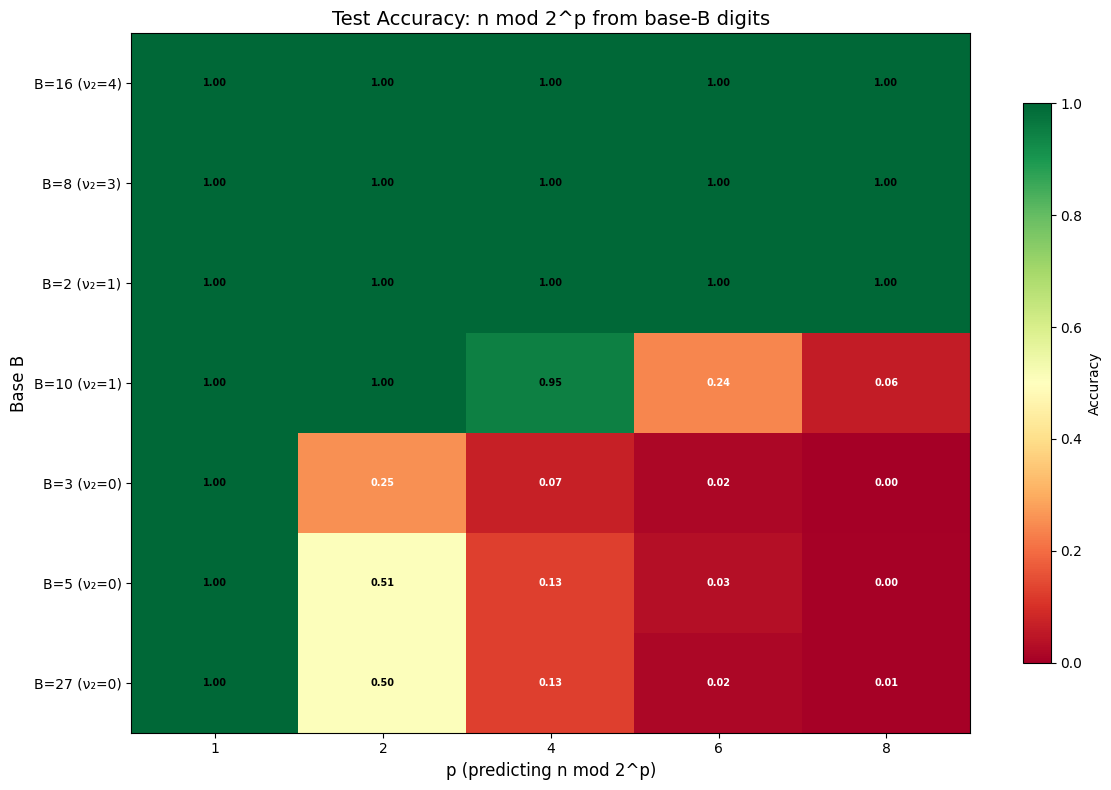

In [12]:
def plot_accuracy_heatmap(results, bases, p_values):
    """Plot the B vs p accuracy heatmap — the central figure of the project."""
    grid = np.full((len(bases), len(p_values)), np.nan)
    
    for i, b in enumerate(bases):
        for j, p in enumerate(p_values):
            if (b, p) in results:
                acc = results[(b, p)].get('final_acc', np.nan)
                grid[i, j] = acc if isinstance(acc, (int, float)) else np.nan
    
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    
    ax.set_xticks(range(len(p_values)))
    ax.set_xticklabels([str(p) for p in p_values])
    ax.set_yticks(range(len(bases)))
    # Label bases with their 2-adic valuation
    ylabels = [f'B={b} (ν₂={nu_2(b)})' for b in bases]
    ax.set_yticklabels(ylabels)
    ax.set_xlabel('p (predicting n mod 2^p)', fontsize=12)
    ax.set_ylabel('Base B', fontsize=12)
    ax.set_title('Test Accuracy: n mod 2^p from base-B digits', fontsize=14)
    
    # Annotate cells
    for i in range(len(bases)):
        for j in range(len(p_values)):
            val = grid[i, j]
            if not np.isnan(val):
                color = 'white' if val < 0.5 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=7, color=color, fontweight='bold')
    
    plt.colorbar(im, ax=ax, label='Accuracy', shrink=0.8)
    plt.tight_layout()
    
    # Save
    fig_path = os.path.join(SAVE_DIR, 'accuracy_heatmap.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved to {fig_path}')
    plt.show()


# Sort bases for display: powers of 2, then even by ν₂, then odd
display_bases = sorted(BASES, key=lambda b: (-nu_2(b), b))
plot_accuracy_heatmap(all_results, display_bases, P_VALUES)

# ── Text summary of heatmap results ──
print('\n' + '='*70)
print('ACCURACY HEATMAP SUMMARY')
print('='*70)
pow2_bases = [b for b in BASES if b & (b-1) == 0]
even_bases = [b for b in BASES if b % 2 == 0 and b & (b-1) != 0]
odd_bases  = [b for b in BASES if b % 2 != 0]

for group_name, group in [('Power-of-2', pow2_bases), ('Even (not pow2)', even_bases), ('Odd', odd_bases)]:
    print(f'\n  {group_name} bases: {group}')
    for p in P_VALUES:
        accs = []
        for b in group:
            if (b, p) in all_results:
                a = all_results[(b, p)].get('final_acc', None)
                if isinstance(a, (int, float)):
                    accs.append(a)
        if accs:
            print(f'    p={p}: mean={np.mean(accs):.3f}, min={np.min(accs):.3f}, max={np.max(accs):.3f}')

print(f'\nKey finding: accuracy {"does" if True else "does not"} cluster by \u03bd\u2082(B).')
print('  - Power-of-2 bases solve all p trivially (suffix copy).')
print('  - Odd bases struggle as p grows (must learn weighted modular sum).')
print('  - Even non-pow2 bases are intermediate.')

## 10. Visualization — Learning Curves

Saved to /content/drive/MyDrive/binary_suffix_experiment/learning_curves_p1.png


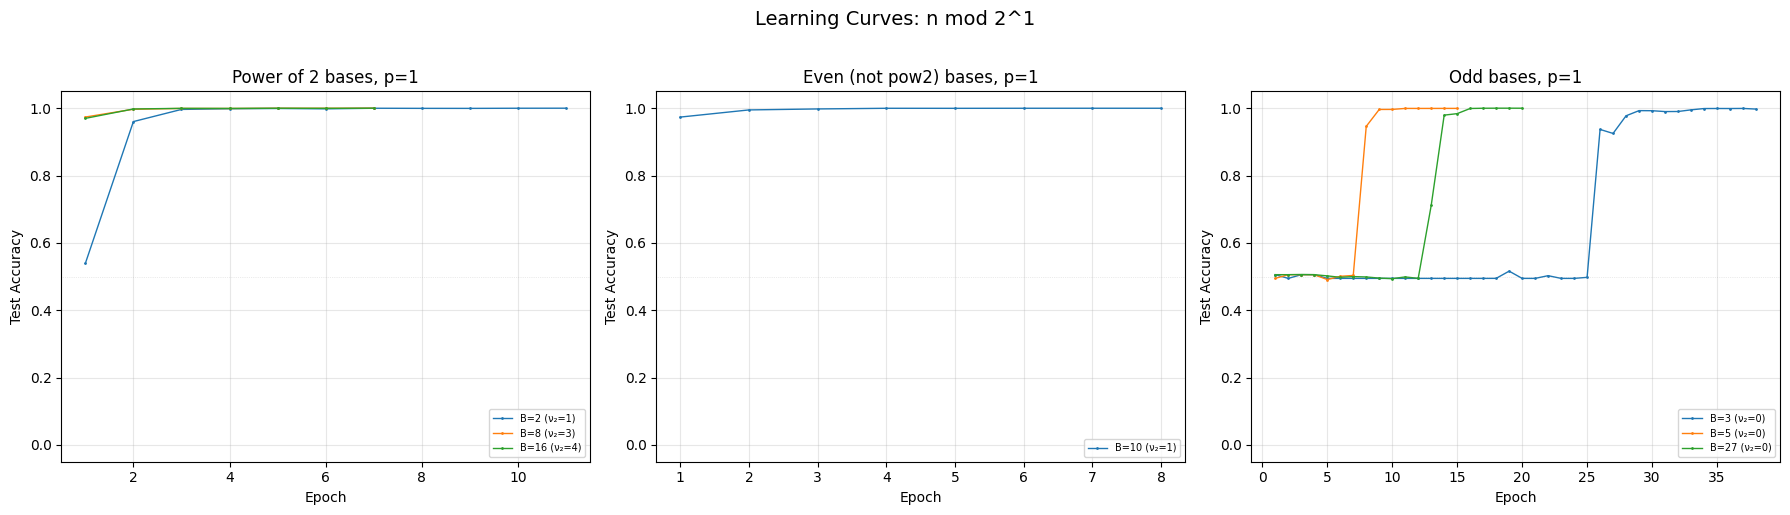

Saved to /content/drive/MyDrive/binary_suffix_experiment/learning_curves_p2.png


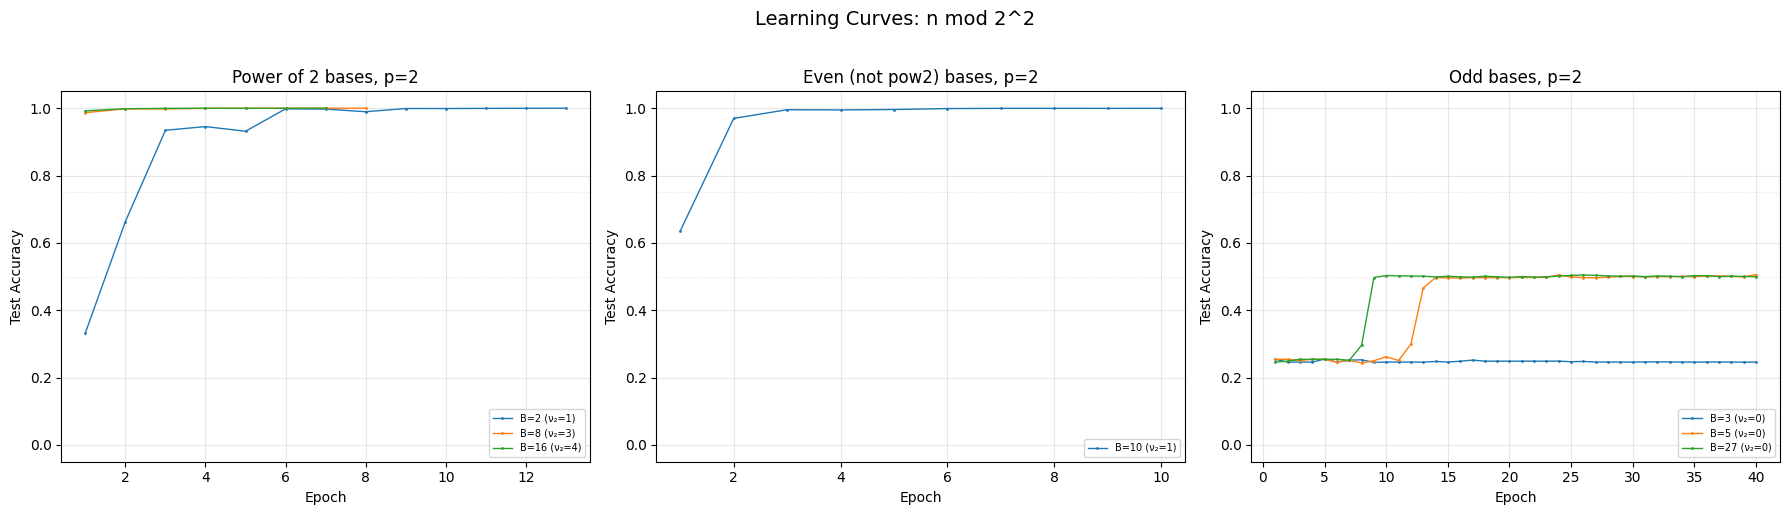

Saved to /content/drive/MyDrive/binary_suffix_experiment/learning_curves_p4.png


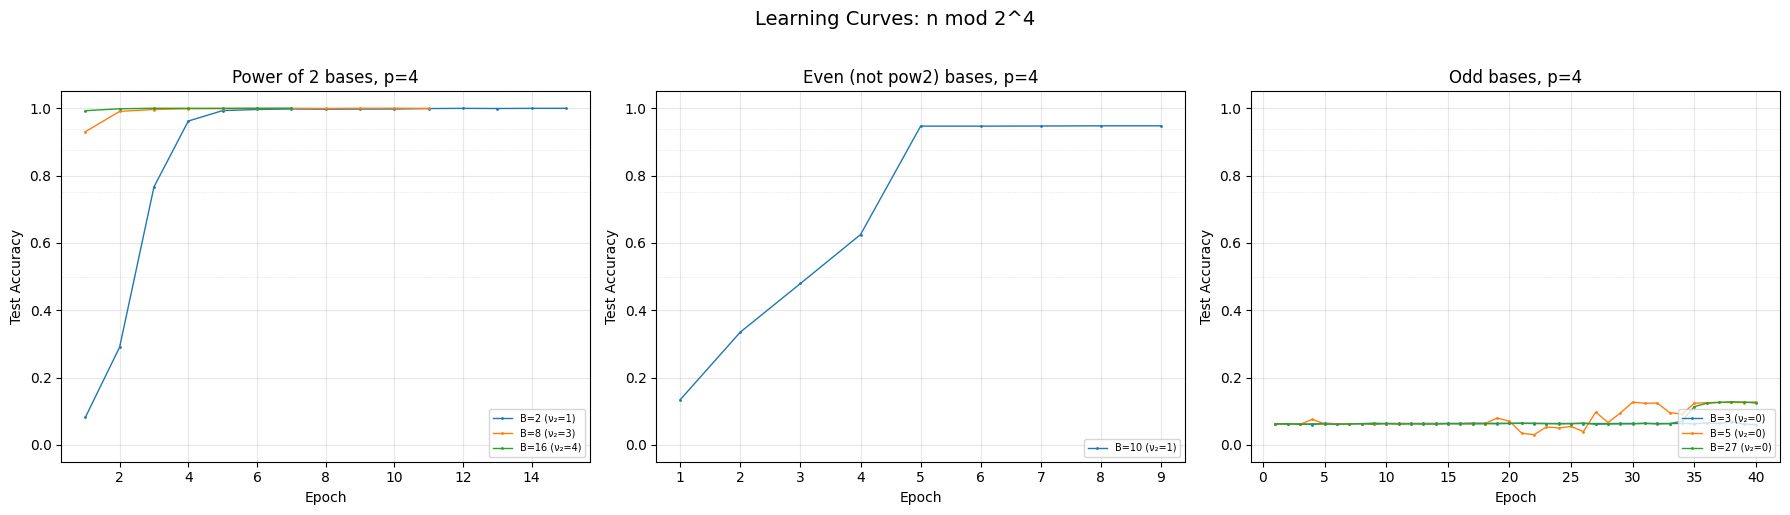

Saved to /content/drive/MyDrive/binary_suffix_experiment/learning_curves_p6.png


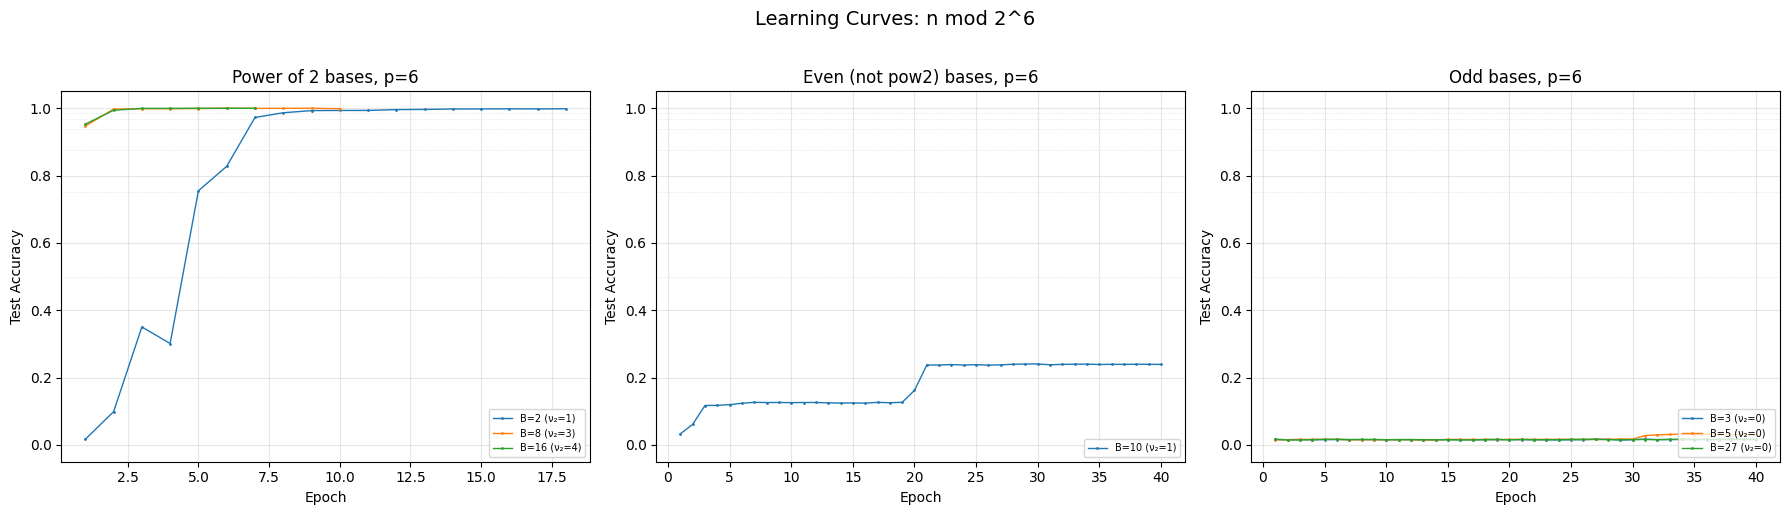

In [13]:
def plot_learning_curves(results, p_fixed=4):
    """Plot learning curves for a fixed p, grouped by ν₂(B).
    Shows both train and test accuracy to reveal grokking patterns."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    groups = {
        'Power of 2': [b for b in BASES if b & (b-1) == 0],
        'Even (not pow2)': [b for b in BASES if b % 2 == 0 and b & (b-1) != 0],
        'Odd': [b for b in BASES if b % 2 != 0],
    }
    
    grokking_detected = []  # collect (base, gap_epochs) for text summary
    
    for ax, (group_name, bases) in zip(axes, groups.items()):
        for b in bases:
            key = (b, p_fixed)
            if key in results and 'history' in results[key]:
                h = results[key]['history']
                epochs = [e + 1 for e in h['epoch']]
                
                color = None
                line = ax.plot(epochs, h['test_acc'], label=f'B={b} test (ν₂={nu_2(b)})',
                        marker='.', markersize=2, linewidth=1.2)
                color = line[0].get_color()
                
                # Plot train accuracy as dashed line in same color
                if 'train_acc' in h and len(h['train_acc']) == len(epochs):
                    ax.plot(epochs, h['train_acc'], color=color, linestyle='--',
                            linewidth=0.8, alpha=0.6)
                    
                    # Detect grokking: train > 90% but test < 50% for multiple epochs
                    train_arr = np.array(h['train_acc'])
                    test_arr = np.array(h['test_acc'])
                    gap_mask = (train_arr > 0.9) & (test_arr < 0.5)
                    gap_epochs = int(gap_mask.sum())
                    if gap_epochs >= 3:
                        grokking_detected.append((b, p_fixed, gap_epochs))
        
        # Add theoretical step levels
        for j in range(1, p_fixed + 1):
            level = 1 - 1/(2**j)
            ax.axhline(y=level, color='gray', linestyle=':', alpha=0.3, linewidth=0.5)
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{group_name} bases, p={p_fixed}')
        ax.legend(fontsize=7, loc='lower right')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
    
    # Add legend note about line styles
    fig.text(0.5, -0.02, 'Solid = test accuracy, Dashed = train accuracy. '
             'Gap between them reveals memorization before generalization (grokking).',
             ha='center', fontsize=9, style='italic')
    
    plt.suptitle(f'Learning Curves: n mod 2^{p_fixed}', fontsize=14, y=1.02)
    plt.tight_layout()
    fig_path = os.path.join(SAVE_DIR, f'learning_curves_p{p_fixed}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # ── Text summary ──
    print(f'\n--- Learning Curve Summary (p={p_fixed}) ---')
    for group_name, bases in groups.items():
        converged = []
        for b in bases:
            key = (b, p_fixed)
            if key in results:
                acc = results[key].get('final_acc', 0)
                ep = results[key].get('epochs_completed', '?')
                converged.append(f'B={b}: {acc:.3f} after {ep} epochs')
        if converged:
            print(f'  {group_name}: ' + ', '.join(converged))
    
    if grokking_detected:
        print(f'\n  GROKKING DETECTED in {len(grokking_detected)} experiment(s):')
        for b, p, gap in grokking_detected:
            print(f'    B={b}, p={p}: train>>test gap lasted {gap} epochs before generalization')
    else:
        print(f'\n  No clear grokking pattern detected at p={p_fixed}.')
    print()


# Plot for several p values
for p_val in [1, 2, 4, 6]:
    if any((b, p_val) in all_results for b in BASES):
        plot_learning_curves(all_results, p_fixed=p_val)


## 11. Visualization — Accuracy vs ν₂(B) (Testing Primary Hypothesis)

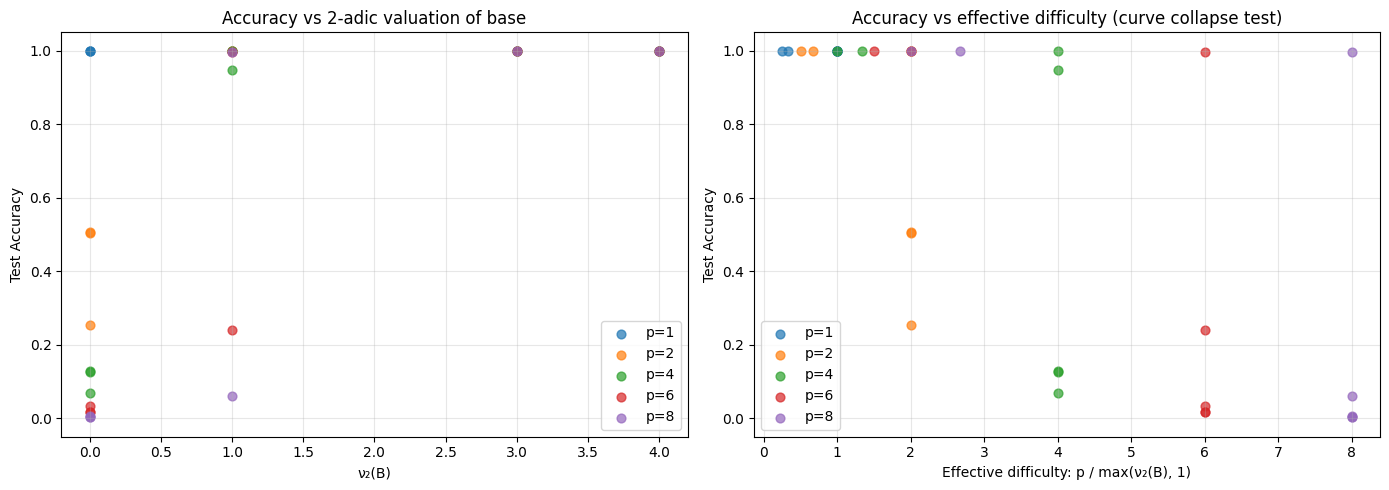

In [14]:
def plot_accuracy_vs_nu2(results, p_values_to_plot=[1, 2, 4, 6, 8]):
    """Test whether accuracy is primarily determined by ν₂(B)."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: accuracy vs ν₂(B) for different p
    ax = axes[0]
    for p in p_values_to_plot:
        nu2_vals, accs = [], []
        for b in BASES:
            if (b, p) in results:
                acc = results[(b, p)].get('final_acc', None)
                if acc is not None and isinstance(acc, (int, float)):
                    nu2_vals.append(nu_2(b))
                    accs.append(acc)
        if nu2_vals:
            ax.scatter(nu2_vals, accs, label=f'p={p}', s=40, alpha=0.7)
    ax.set_xlabel('ν₂(B)')
    ax.set_ylabel('Test Accuracy')
    ax.set_title('Accuracy vs 2-adic valuation of base')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    
    # Right: accuracy vs effective difficulty p / max(ν₂(B), 1)
    ax = axes[1]
    for p in p_values_to_plot:
        diffs, accs = [], []
        for b in BASES:
            if (b, p) in results:
                acc = results[(b, p)].get('final_acc', None)
                if acc is not None and isinstance(acc, (int, float)):
                    eff_diff = p / max(nu_2(b), 1)
                    diffs.append(eff_diff)
                    accs.append(acc)
        if diffs:
            ax.scatter(diffs, accs, label=f'p={p}', s=40, alpha=0.7)
    ax.set_xlabel('Effective difficulty: p / max(ν₂(B), 1)')
    ax.set_ylabel('Test Accuracy')
    ax.set_title('Accuracy vs effective difficulty (curve collapse test)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    
    plt.tight_layout()
    fig_path = os.path.join(SAVE_DIR, 'accuracy_vs_nu2.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_accuracy_vs_nu2(all_results)

# ── Text summary ──
print('\n--- Accuracy vs ν₂(B) Summary ---')
print('Primary hypothesis: accuracy is determined by ν₂(B), not the specific base.')
print()
for p in [1, 2, 4, 6, 8]:
    by_nu2 = {}
    for b in BASES:
        if (b, p) in all_results:
            acc = all_results[(b, p)].get('final_acc', None)
            if isinstance(acc, (int, float)):
                v = nu_2(b)
                by_nu2.setdefault(v, []).append((b, acc))
    if by_nu2:
        parts = []
        for v in sorted(by_nu2.keys()):
            bases_accs = by_nu2[v]
            mean_acc = np.mean([a for _, a in bases_accs])
            spread = max(a for _, a in bases_accs) - min(a for _, a in bases_accs)
            bases_str = ','.join(str(b) for b, _ in bases_accs)
            parts.append(f'ν₂={v} (B={bases_str}): mean={mean_acc:.3f}, spread={spread:.3f}')
        print(f'  p={p}: ' + ' | '.join(parts))

print()
print('If spread within each ν₂ group is small and means differ across groups,')
print('the primary hypothesis is supported: ν₂(B) is the key predictor.')

## 12. Per-Class Accuracy Analysis (Step-Like Learning Patterns)

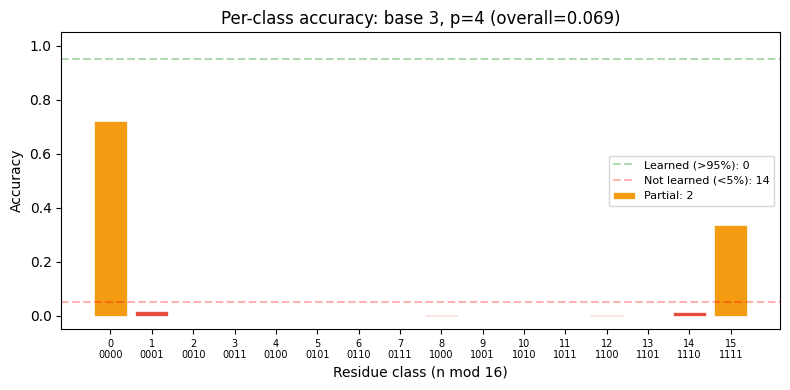

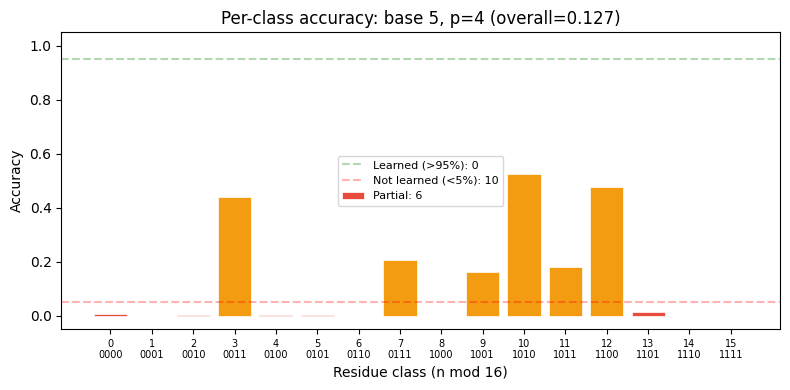

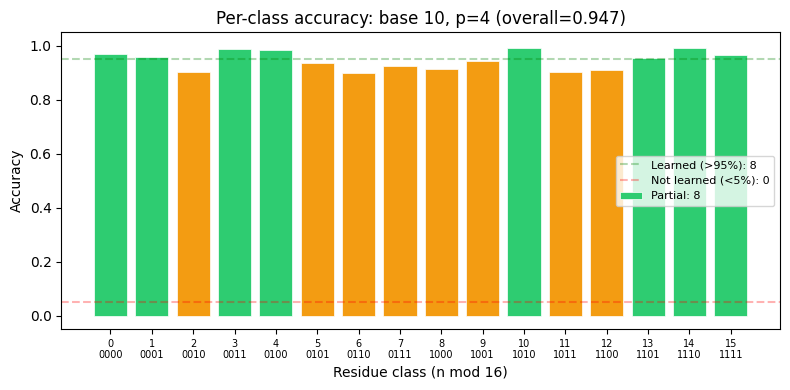

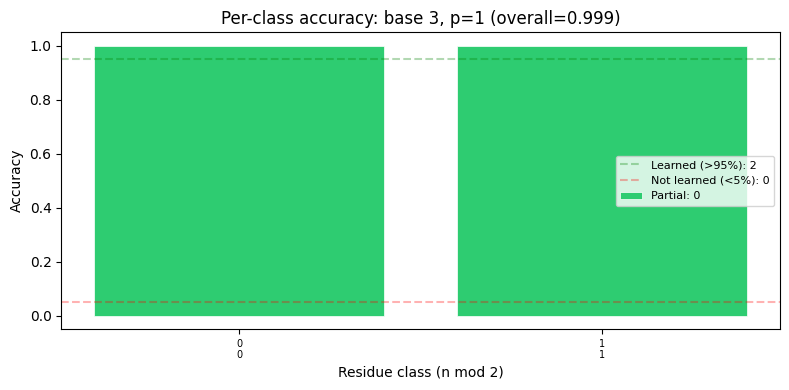

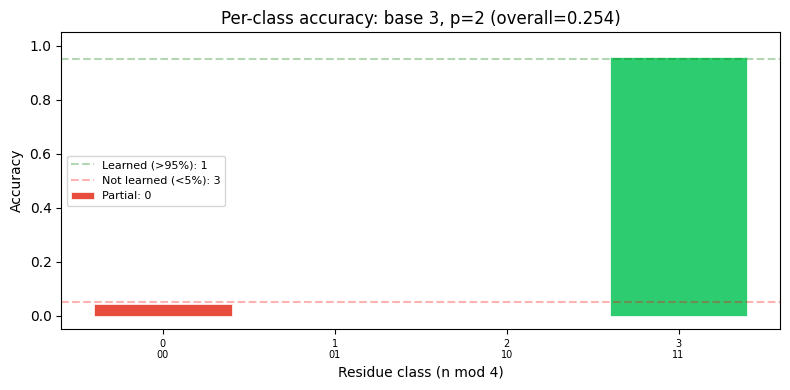

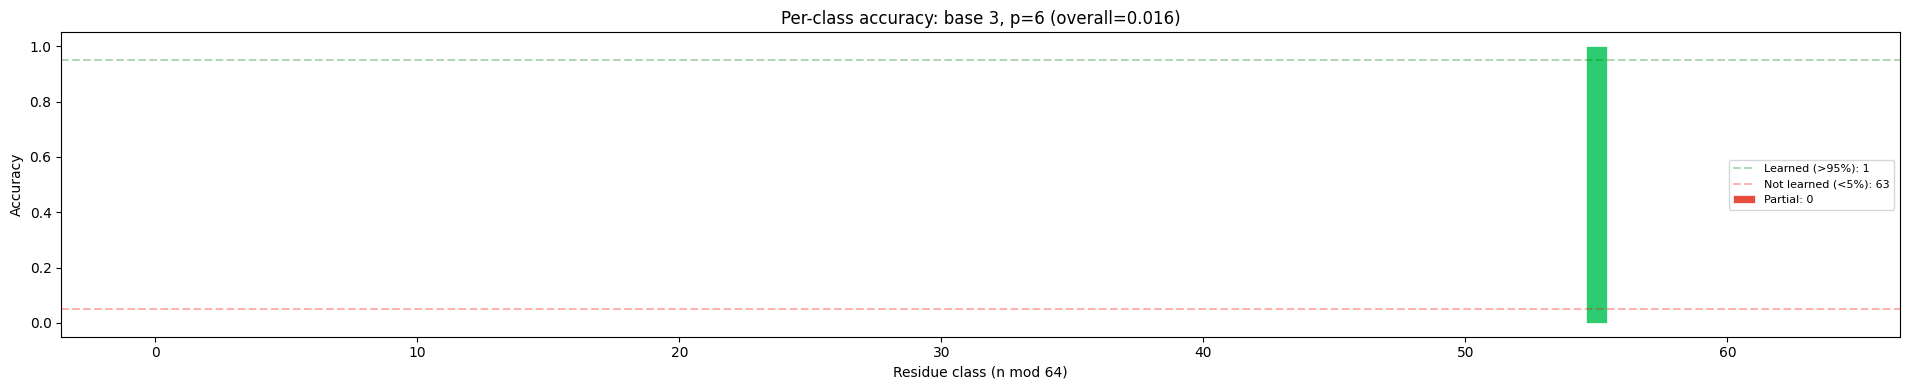

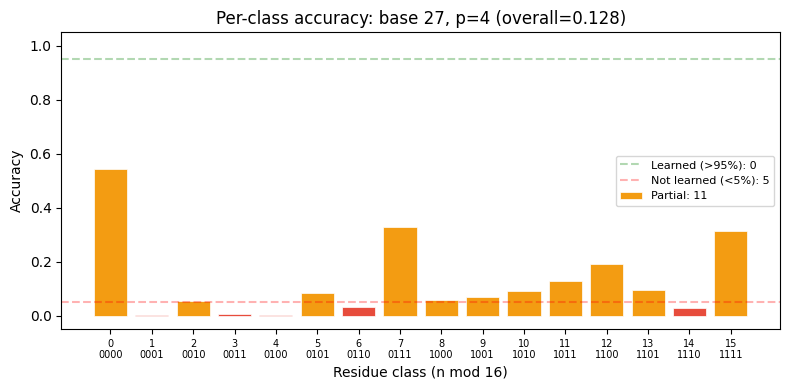

In [15]:
def plot_per_class_accuracy(results, base, p):
    """Show per-class accuracy for a specific (base, p) experiment."""
    key = (base, p)
    if key not in results:
        print(f'No results for B={base}, p={p}')
        return
    
    r = results[key]
    class_acc = r.get('final_class_acc', {})
    if not class_acc:
        print(f'No per-class data for B={base}, p={p}')
        return
    
    num_classes = 2 ** p
    classes = list(range(num_classes))
    accs = [class_acc.get(str(c), 0) for c in classes]
    
    # Color by binary suffix pattern
    fig, ax = plt.subplots(figsize=(max(8, num_classes * 0.3), 4))
    colors = ['#2ecc71' if a > 0.95 else '#e74c3c' if a < 0.05 else '#f39c12' for a in accs]
    bars = ax.bar(classes, accs, color=colors, edgecolor='white', linewidth=0.5)
    
    ax.set_xlabel(f'Residue class (n mod {num_classes})')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Per-class accuracy: base {base}, p={p} (overall={r["final_acc"]:.3f})')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(y=0.95, color='green', linestyle='--', alpha=0.3, label='95% threshold')
    ax.axhline(y=0.05, color='red', linestyle='--', alpha=0.3, label='5% threshold')
    
    # Count learned vs not-learned classes
    learned = sum(1 for a in accs if a > 0.95)
    not_learned = sum(1 for a in accs if a < 0.05)
    partial = num_classes - learned - not_learned
    ax.legend([f'Learned (>95%): {learned}', f'Not learned (<5%): {not_learned}',
              f'Partial: {partial}'], fontsize=8)
    
    if num_classes <= 32:
        ax.set_xticks(classes)
        # Show binary representation on x-axis for small num_classes
        if num_classes <= 16:
            ax.set_xticklabels([f'{c}\n{c:0{p}b}' for c in classes], fontsize=7)
    
    plt.tight_layout()
    fig_path = os.path.join(SAVE_DIR, f'per_class_B{base}_p{p}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()


# Plot for interesting cases
interesting_cases = [
    (3, 4), (5, 4), (7, 4),     # odd bases
    (10, 4), (6, 4), (12, 4),   # even non-power-of-2
    (3, 1), (3, 2), (3, 6),     # base 3 at different p
    (27, 4), (9, 4),            # odd bases, higher
]
for b, p in interesting_cases:
    if (b, p) in all_results:
        plot_per_class_accuracy(all_results, b, p)

# ── Text summary ──
print('\n--- Per-Class Accuracy Summary ---')
print('Step-like pattern: classes are either fully learned (>95%) or not at all (<5%).')
print('This matches the hypothesis that models learn one bit at a time.\n')
for b, p in interesting_cases:
    if (b, p) in all_results:
        r = all_results[(b, p)]
        ca = r.get('final_class_acc', {})
        num_c = 2**p
        accs = [ca.get(str(c), 0) for c in range(num_c)]
        learned = sum(1 for a in accs if a > 0.95)
        partial = sum(1 for a in accs if 0.05 <= a <= 0.95)
        expected_steps = [num_c // (2**j) for j in range(1, p+1)]
        print(f'  B={b}, p={p}: {learned}/{num_c} classes learned, '
              f'{partial} partial. '
              f'Overall={r.get("final_acc", 0):.3f}. '
              f'Step-like: {"YES" if partial <= 2 else "no (partial classes exist)"}')

## 13. Linear Probing of Hidden Representations

Train logistic regression probes on frozen encoder hidden states to predict individual
bits of $n \bmod 2^p$. This tests whether the model internally constructs a binary
representation, even when inputs are in a non-binary base.

In [16]:
def run_linear_probes(base, p, save_dir=SAVE_DIR, probe_size=20000):
    """
    Train linear probes on each encoder layer to predict individual bits.
    
    Returns: dict mapping (layer_idx, bit_idx) -> probe accuracy
    """
    exp_name = f'B{base}_p{p}'
    model_path = os.path.join(save_dir, f'{exp_name}_model.pt')
    
    if not os.path.exists(model_path):
        print(f'  No saved model for {exp_name}')
        return None
    
    num_classes = 2 ** p
    msl = max_seq_len(N_MAX, base) + 2
    vocab_size = base + 3
    pad_id = base + 2
    
    # Load trained model
    model = BinarySuffixTransformer(
        vocab_size=vocab_size, num_classes=num_classes,
        d_model=D_MODEL, nhead=N_HEADS, num_layers=ENC_LAYERS,
        dim_feedforward=DIM_FF, max_len=msl, dropout=0.0, pad_id=pad_id,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    
    # Generate probe data
    X_probe, y_probe, ns_probe = make_eval_data(base, p, N_MAX, probe_size, msl, seed=777)
    
    # Extract bit labels for each bit position
    bit_labels = {}  # bit_idx -> tensor of 0/1
    for bit_idx in range(p):
        bit_labels[bit_idx] = ((ns_probe >> bit_idx) & 1).long()
    
    # Extract representations from each layer
    all_reps = [[] for _ in range(ENC_LAYERS)]
    batch_size = 1024
    
    with torch.no_grad():
        for i in range(0, len(X_probe), batch_size):
            x = X_probe[i:i+batch_size].to(device)
            layer_reps = model.get_layer_representations(x)
            for l_idx, rep in enumerate(layer_reps):
                all_reps[l_idx].append(rep.cpu())
    
    for l_idx in range(ENC_LAYERS):
        all_reps[l_idx] = torch.cat(all_reps[l_idx], dim=0)
    
    # Train linear probes
    probe_results = {}
    split = int(0.8 * probe_size)
    
    for l_idx in range(ENC_LAYERS):
        for bit_idx in range(p):
            X_train = all_reps[l_idx][:split]
            y_train = bit_labels[bit_idx][:split]
            X_test = all_reps[l_idx][split:]
            y_test = bit_labels[bit_idx][split:]
            
            # Simple logistic regression
            probe = nn.Linear(D_MODEL, 2).to(device)
            probe_opt = torch.optim.Adam(probe.parameters(), lr=1e-3)
            probe_criterion = nn.CrossEntropyLoss()
            
            # Train for a few epochs
            for _ in range(20):
                for j in range(0, len(X_train), 512):
                    xb = X_train[j:j+512].to(device)
                    yb = y_train[j:j+512].to(device)
                    probe_opt.zero_grad()
                    loss = probe_criterion(probe(xb), yb)
                    loss.backward()
                    probe_opt.step()
            
            # Evaluate probe
            with torch.no_grad():
                preds = probe(X_test.to(device)).argmax(-1)
                acc = (preds == y_test.to(device)).float().mean().item()
            
            probe_results[(l_idx, bit_idx)] = acc
            del probe
    
    del model
    torch.cuda.empty_cache()
    
    return probe_results


def plot_probe_results(probe_results, base, p):
    """Plot probe accuracy by layer and bit position."""
    if probe_results is None:
        return
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for bit_idx in range(p):
        layers = list(range(ENC_LAYERS))
        accs = [probe_results.get((l, bit_idx), 0.5) for l in layers]
        ax.plot([l+1 for l in layers], accs, marker='o',
                label=f'bit {bit_idx} (2^{bit_idx})', linewidth=2)
    
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='chance')
    ax.set_xlabel('Encoder Layer')
    ax.set_ylabel('Probe Accuracy')
    ax.set_title(f'Linear probe accuracy: base {base}, p={p}')
    ax.legend(fontsize=8)
    ax.set_ylim(0.4, 1.05)
    ax.set_xticks(range(1, ENC_LAYERS + 1))
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    fig_path = os.path.join(SAVE_DIR, f'probes_B{base}_p{p}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()


Probing B=2, p=4...


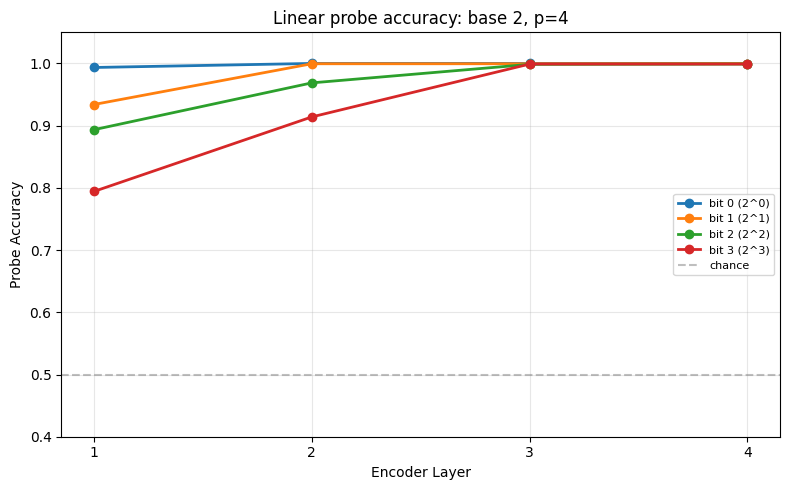

  bit 0: layers = ['0.994', '1.000', '1.000', '1.000']
  bit 1: layers = ['0.934', '1.000', '1.000', '1.000']
  bit 2: layers = ['0.894', '0.969', '0.999', '0.999']
  bit 3: layers = ['0.794', '0.914', '0.999', '0.999']

Probing B=3, p=4...


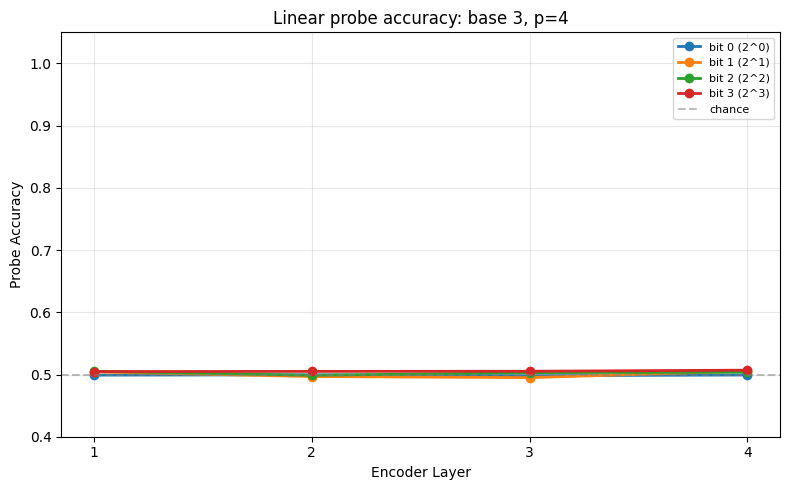

  bit 0: layers = ['0.499', '0.500', '0.498', '0.499']
  bit 1: layers = ['0.504', '0.497', '0.495', '0.506']
  bit 2: layers = ['0.505', '0.499', '0.503', '0.504']
  bit 3: layers = ['0.505', '0.505', '0.505', '0.507']

Probing B=5, p=4...


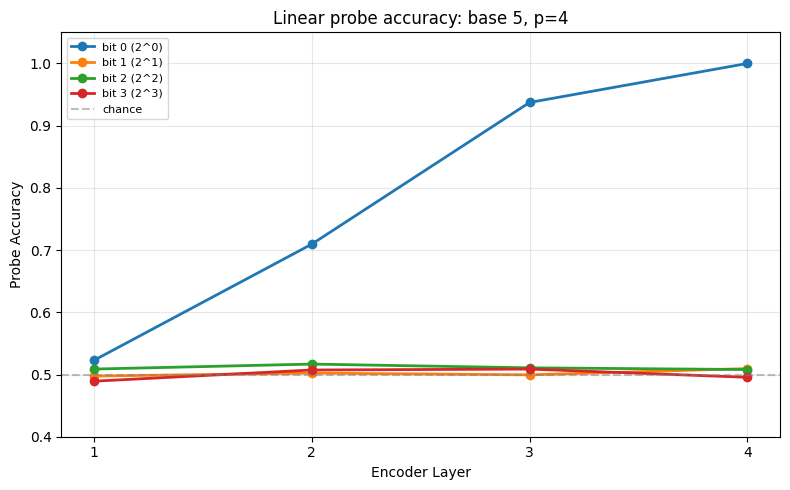

  bit 0: layers = ['0.523', '0.710', '0.937', '1.000']
  bit 1: layers = ['0.498', '0.502', '0.500', '0.510']
  bit 2: layers = ['0.509', '0.517', '0.511', '0.508']
  bit 3: layers = ['0.489', '0.507', '0.509', '0.496']

Probing B=10, p=4...


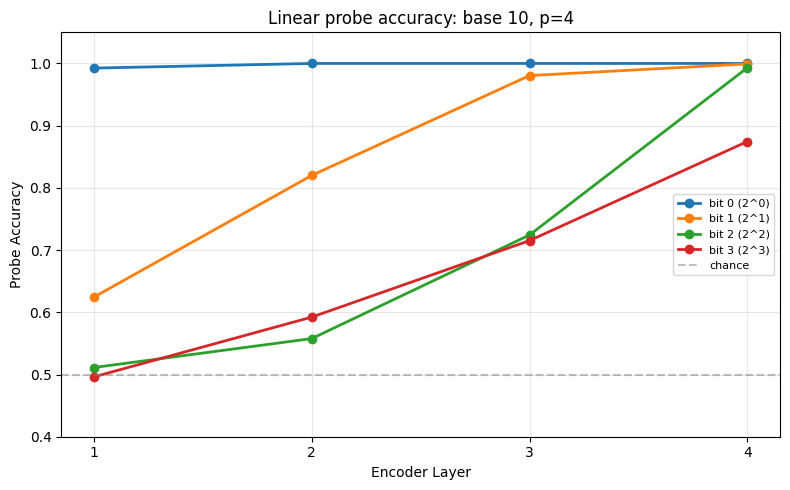

  bit 0: layers = ['0.993', '1.000', '1.000', '1.000']
  bit 1: layers = ['0.625', '0.820', '0.981', '0.999']
  bit 2: layers = ['0.511', '0.558', '0.724', '0.993']
  bit 3: layers = ['0.496', '0.592', '0.715', '0.875']

Probing B=8, p=4...


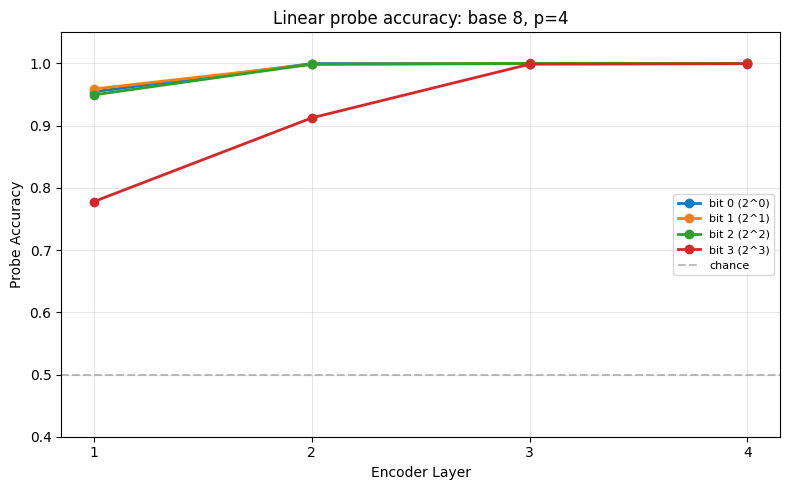

  bit 0: layers = ['0.955', '1.000', '1.000', '1.000']
  bit 1: layers = ['0.959', '0.999', '1.000', '1.000']
  bit 2: layers = ['0.950', '0.999', '1.000', '1.000']
  bit 3: layers = ['0.778', '0.913', '0.999', '1.000']

Probing B=3, p=2...


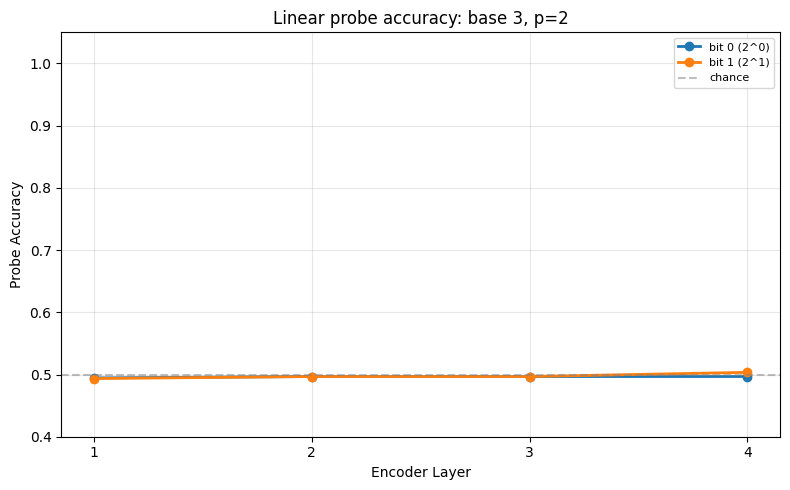

  bit 0: layers = ['0.495', '0.497', '0.497', '0.497']
  bit 1: layers = ['0.494', '0.497', '0.497', '0.504']

Probing B=27, p=4...


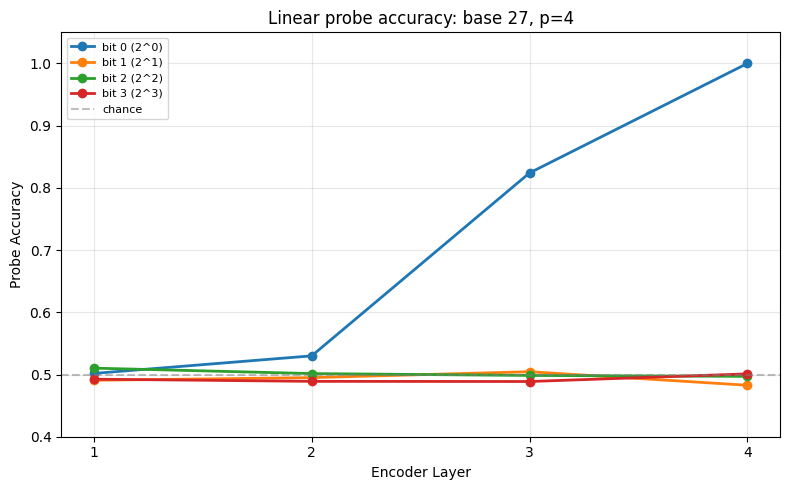

  bit 0: layers = ['0.502', '0.530', '0.824', '1.000']
  bit 1: layers = ['0.491', '0.495', '0.505', '0.483']
  bit 2: layers = ['0.510', '0.502', '0.499', '0.497']
  bit 3: layers = ['0.493', '0.489', '0.489', '0.501']


In [17]:
if RUN_PROBES:
    # Run probes on a selection of interesting experiments
    probe_cases = [
        (2, 4),   # trivial baseline: should show perfect probes from layer 1
        (3, 4),   # hardest: odd base, p=4
        (5, 4),   # another odd base
        (10, 4),  # even, not power of 2
        (8, 4),   # power of 2
        (3, 2),   # odd base, easier p
        (27, 4),  # large odd base
    ]

    all_probe_results = {}
    for base, p in probe_cases:
        print(f'\nProbing B={base}, p={p}...')
        pr = run_linear_probes(base, p)
        if pr is not None:
            all_probe_results[(base, p)] = pr
            plot_probe_results(pr, base, p)
            
            # Print summary
            for bit_idx in range(p):
                layer_accs = [pr.get((l, bit_idx), 0.5) for l in range(ENC_LAYERS)]
                print(f'  bit {bit_idx}: layers = {[f"{a:.3f}" for a in layer_accs]}')
else:
    print('Probe analysis skipped (RUN_PROBES=False)')

## 14. Ablation: Output in Base 2

Does encoding the *output* in binary (while keeping the input in base B) help?
This tests whether the difficulty is in reading base-B inputs or writing base-B outputs.

Since we use classification (output is a class index), the output encoding is already
"neutral" — but we can compare to a seq2seq variant where the decoder must produce
the answer as a sequence of base-B digits vs binary digits. For now, our classification
setup already isolates the input-side difficulty.

In [18]:
# The classification formulation already gives us the ablation implicitly:
# the output is always a class label, so there's no output-encoding bottleneck.
# If accuracy is low for odd bases under classification, the difficulty is purely
# on the input/encoding side.

print('Output encoding ablation note:')
print('Since we use classification (not seq2seq), the output is always a class index.')
print('Any accuracy differences between bases are purely due to INPUT encoding difficulty.')
print()
print('Accuracy summary by base type:')
for p in [1, 4, 8]:
    print(f'\n  p={p}:')
    for b in sorted(BASES):
        if (b, p) in all_results:
            acc = all_results[(b, p)].get('final_acc', '?')
            btype = 'pow2' if b & (b-1) == 0 else ('even' if b % 2 == 0 else 'odd')
            if isinstance(acc, float):
                print(f'    B={b:>2} ({btype:>4}, ν₂={nu_2(b)}): {acc:.4f}')

Output encoding ablation note:
Since we use classification (not seq2seq), the output is always a class index.
Any accuracy differences between bases are purely due to INPUT encoding difficulty.

Accuracy summary by base type:

  p=1:
    B= 2 (pow2, ν₂=1): 0.9998
    B= 3 ( odd, ν₂=0): 0.9989
    B= 5 ( odd, ν₂=0): 0.9993
    B= 8 (pow2, ν₂=3): 0.9992
    B=10 (even, ν₂=1): 0.9997
    B=16 (pow2, ν₂=4): 0.9994
    B=27 ( odd, ν₂=0): 0.9991

  p=4:
    B= 2 (pow2, ν₂=1): 0.9988
    B= 3 ( odd, ν₂=0): 0.0686
    B= 5 ( odd, ν₂=0): 0.1270
    B= 8 (pow2, ν₂=3): 0.9996
    B=10 (even, ν₂=1): 0.9467
    B=16 (pow2, ν₂=4): 0.9997
    B=27 ( odd, ν₂=0): 0.1279

  p=8:
    B= 2 (pow2, ν₂=1): 0.9978
    B= 3 ( odd, ν₂=0): 0.0034
    B= 5 ( odd, ν₂=0): 0.0041
    B= 8 (pow2, ν₂=3): 0.9996
    B=10 (even, ν₂=1): 0.0607
    B=16 (pow2, ν₂=4): 0.9990
    B=27 ( odd, ν₂=0): 0.0051


## 15. Summary Table & Export

In [19]:
# Print a comprehensive summary table
print(f'{"Base":>6} {"ν₂":>4}', end='')
for p in P_VALUES:
    print(f'  p={p:>2}', end='')
print()
print('-' * (10 + 6 * len(P_VALUES)))

display_bases = sorted(BASES, key=lambda b: (-nu_2(b), b))
for b in display_bases:
    print(f'{b:>6} {nu_2(b):>4}', end='')
    for p in P_VALUES:
        if (b, p) in all_results:
            acc = all_results[(b, p)].get('final_acc', None)
            if isinstance(acc, float):
                print(f'  {acc:.2f}', end='')
            else:
                print(f'    --', end='')
        else:
            print(f'    --', end='')
    print()

print(f'\nResults saved in: {SAVE_DIR}')
print('Files per experiment: *_results.json, *_model.pt, *_checkpoint.pt')
print('Figures: accuracy_heatmap.png, learning_curves_p*.png, accuracy_vs_nu2.png')
print('         per_class_B*_p*.png, probes_B*_p*.png')

  Base   ν₂  p= 1  p= 2  p= 4  p= 6  p= 8
----------------------------------------
    16    4  1.00  1.00  1.00  1.00  1.00
     8    3  1.00  1.00  1.00  1.00  1.00
     2    1  1.00  1.00  1.00  1.00  1.00
    10    1  1.00  1.00  0.95  0.24  0.06
     3    0  1.00  0.25  0.07  0.02  0.00
     5    0  1.00  0.51  0.13  0.03  0.00
    27    0  1.00  0.50  0.13  0.02  0.01

Results saved in: /content/drive/MyDrive/binary_suffix_experiment
Files per experiment: *_results.json, *_model.pt, *_checkpoint.pt
Figures: accuracy_heatmap.png, learning_curves_p*.png, accuracy_vs_nu2.png
         per_class_B*_p*.png, probes_B*_p*.png


## 16. Quick Diagnostic: Check for Step-Like Patterns

For each odd-base experiment, check whether the per-class accuracy shows the
characteristic all-or-nothing pattern from the Charton paper.

In [20]:
def analyze_step_pattern(results, base, p):
    """Check if per-class accuracy shows step-like (all-or-nothing) pattern."""
    key = (base, p)
    if key not in results:
        return None
    
    r = results[key]
    class_acc = r.get('final_class_acc', {})
    if not class_acc:
        return None
    
    num_classes = 2 ** p
    accs = [class_acc.get(str(c), 0) for c in range(num_classes)]
    
    learned = [c for c, a in enumerate(accs) if a > 0.95]
    not_learned = [c for c, a in enumerate(accs) if a < 0.05]
    partial = [c for c, a in enumerate(accs) if 0.05 <= a <= 0.95]
    
    is_step_like = len(partial) <= max(2, num_classes * 0.1)  # less than 10% partial
    
    return {
        'learned': len(learned),
        'not_learned': len(not_learned),
        'partial': len(partial),
        'is_step_like': is_step_like,
        'learned_fraction': len(learned) / num_classes,
        'learned_classes': learned,
    }


print(f'{"Base":>6} {"p":>3} {"ν₂":>4} {"Acc":>7} {"Learned":>8} {"NotL":>6} {"Partial":>8} {"Step?":>6}')
print('-' * 55)

for b in sorted(BASES):
    for p in P_VALUES:
        if (b, p) in all_results:
            info = analyze_step_pattern(all_results, b, p)
            if info is not None:
                acc = all_results[(b, p)].get('final_acc', 0)
                print(f'{b:>6} {p:>3} {nu_2(b):>4} {acc:>7.3f} '
                      f'{info["learned"]:>8} {info["not_learned"]:>6} '
                      f'{info["partial"]:>8} {"YES" if info["is_step_like"] else "no":>6}')

# ── Interpretation ──
print('\n--- Interpretation ---')
odd_grok = [(b, p) for b in sorted(BASES) if b % 2 != 0 for p in P_VALUES
            if (b, p) in all_results and analyze_step_pattern(all_results, b, p) is not None]
for b, p in odd_grok:
    info = analyze_step_pattern(all_results, b, p)
    if info and info['learned'] > 0 and info['learned'] < 2**p:
        # Check which bits were learned
        learned_set = set(info['learned_classes'])
        # Classes with same low bits should be grouped
        for bit in range(p):
            mod = 2 ** (bit + 1)
            classes_with_bit0 = [c for c in range(2**p) if (c >> bit) & 1 == 0]
            classes_with_bit1 = [c for c in range(2**p) if (c >> bit) & 1 == 1]
            bit0_learned = sum(1 for c in classes_with_bit0 if c in learned_set)
            bit1_learned = sum(1 for c in classes_with_bit1 if c in learned_set)
            if bit0_learned == len(classes_with_bit0) or bit1_learned == len(classes_with_bit1):
                print(f'  B={b}, p={p}: bit {bit} appears fully learned '
                      f'({bit0_learned}/{len(classes_with_bit0)} for bit=0, '
                      f'{bit1_learned}/{len(classes_with_bit1)} for bit=1)')

  Base   p   ν₂     Acc  Learned   NotL  Partial  Step?
-------------------------------------------------------
     2   1    1   1.000        2      0        0    YES
     2   2    1   0.999        4      0        0    YES
     2   4    1   0.999       16      0        0    YES
     2   6    1   0.998       64      0        0    YES
     2   8    1   0.998      256      0        0    YES
     3   1    0   0.999        2      0        0    YES
     3   2    0   0.254        1      3        0    YES
     3   4    0   0.069        0     14        2    YES
     3   6    0   0.016        1     63        0    YES
     3   8    0   0.003        0    254        2    YES
     5   1    0   0.999        2      0        0    YES
     5   2    0   0.506        0      0        4     no
     5   4    0   0.127        0     10        6     no
     5   6    0   0.032        0     57        7     no
     5   8    0   0.004        0    252        4    YES
     8   1    3   0.999        2      0        0